In [0]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt

In [0]:
pandas.core.frame.DataFrame

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-4514966954718676>, line 1
----> 1 pandas.core.frame.DataFrame

NameError: name 'pandas' is not defined

In [0]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
   '/Volumes/datascience_team_testing/eason_test/upload_files/Large_Customer_Churn_Dataset.csv')

df.head()


,CustomerID,Gender,Age,Geography,Tenure,Contract,MonthlyCharges,TotalCharges,PaymentMethod,IsActiveMember,Churn
0,1000001,Male,34,France,14,Two-year,21.58,7933.34,Bank transfer,1,No
1,1000002,Female,26,Spain,14,Month-to-month,27.71,5869.34,Credit card,0,Yes
2,1000003,Male,50,Germany,57,Two-year,111.12,6321.20,Bank transfer,1,No
3,1000004,Male,37,Spain,34,Month-to-month,55.49,7956.44,Bank transfer,0,Yes
4,1000005,Male,30,Spain,53,Two-year,62.48,4922.75,Direct debit,1,No


In [0]:
# Get the max tenure
print(df['Tenure'].max()) 

59


In [0]:
print(df['Age'].max()) 

69


In [0]:
# Group the tenure in bins of 12 months
labels = ["{0} - {1}".format(i, i + 9) for i in range(1, 59, 10)]

df['tenure_group'] = pd.cut(df.Tenure, range(1, 70, 10), right=False, labels=labels)

In [0]:
# Group the tenure in bins of 12 months
labels = ["{0} - {1}".format(i, i + 9) for i in range(1, 69, 10)]

df['age_group'] = pd.cut(df.Age, range(1, 80, 10), right=False, labels=labels)

In [0]:
df['age_group'].value_counts()

age_group
41 - 50    195
51 - 60    192
21 - 30    188
61 - 70    185
31 - 40    182
11 - 20     58
1 - 10       0
Name: count, dtype: int64

In [0]:
df['tenure_group'].value_counts()

tenure_group
41 - 50    181
21 - 30    180
31 - 40    161
11 - 20    160
51 - 60    160
1 - 10     158
Name: count, dtype: int64

In [0]:
df.head()

,CustomerID,Gender,Age,Geography,Tenure,Contract,MonthlyCharges,TotalCharges,PaymentMethod,IsActiveMember,Churn,tenure_group,age_group
0,1000001,Male,34,France,14,Two-year,21.58,7933.34,Bank transfer,1,No,11 - 20,31 - 40
1,1000002,Female,26,Spain,14,Month-to-month,27.71,5869.34,Credit card,0,Yes,11 - 20,21 - 30
2,1000003,Male,50,Germany,57,Two-year,111.12,6321.20,Bank transfer,1,No,51 - 60,41 - 50
3,1000004,Male,37,Spain,34,Month-to-month,55.49,7956.44,Bank transfer,0,Yes,31 - 40,31 - 40
4,1000005,Male,30,Spain,53,Two-year,62.48,4922.75,Direct debit,1,No,51 - 60,21 - 30


In [0]:
#drop column customerID and tenure
df.drop(columns= ['CustomerID','Tenure'], inplace=True)
df.head()

,Gender,Age,Geography,Contract,MonthlyCharges,TotalCharges,PaymentMethod,IsActiveMember,Churn,tenure_group,age_group
0,Male,34,France,Two-year,21.58,7933.34,Bank transfer,1,No,11 - 20,31 - 40
1,Female,26,Spain,Month-to-month,27.71,5869.34,Credit card,0,Yes,11 - 20,21 - 30
2,Male,50,Germany,Two-year,111.12,6321.20,Bank transfer,1,No,51 - 60,41 - 50
3,Male,37,Spain,Month-to-month,55.49,7956.44,Bank transfer,0,Yes,31 - 40,31 - 40
4,Male,30,Spain,Two-year,62.48,4922.75,Direct debit,1,No,51 - 60,21 - 30


In [0]:
df_dummies = pd.get_dummies(df)
df_dummies.head()

,Age,MonthlyCharges,TotalCharges,IsActiveMember,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,Geography_Spain,Geography_UK,Contract_Month-to-month,Contract_One-year,Contract_Two-year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Direct debit,PaymentMethod_Electronic check,Churn_No,Churn_Yes,tenure_group_1 - 10,tenure_group_11 - 20,tenure_group_21 - 30,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,34,21.58,7933.34,1,False,True,True,False,False,False,False,False,False,True,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False
1,26,27.71,5869.34,0,True,False,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False
2,50,111.12,6321.20,1,False,True,False,True,False,False,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False
3,37,55.49,7956.44,0,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False
4,30,62.48,4922.75,1,False,True,False,False,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False


In [0]:
df.isnull().sum()

Gender            0
Age               0
Geography         0
Contract          0
MonthlyCharges    0
TotalCharges      0
PaymentMethod     0
IsActiveMember    0
Churn             0
tenure_group      0
age_group         0
dtype: int64

In [0]:
df.describe()

,Age,MonthlyCharges,TotalCharges,IsActiveMember
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.799000,70.124000,4066.221960,0.503000
std,15.133857,28.476322,2233.265597,0.500241
min,18.000000,20.130000,201.450000,0.000000
25%,31.000000,45.737500,2190.175000,0.000000
50%,44.000000,70.670000,4039.230000,1.000000
75%,57.000000,95.192500,5993.272500,1.000000
max,69.000000,119.760000,7973.210000,1.000000


In [0]:
df.dtypes

Gender              object
Age                  int64
Geography           object
Contract            object
MonthlyCharges     float64
TotalCharges       float64
PaymentMethod       object
IsActiveMember       int64
Churn               object
tenure_group      category
age_group         category
dtype: object

In [0]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill missing 'TotalCharges' with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [0]:
churn_counts = df['Churn'].value_counts()
display(churn_counts)

Churn
1    502
0    498
Name: count, dtype: int64

In [0]:
df['Churn'] = np.where(df.Churn == 'Yes',1,0)

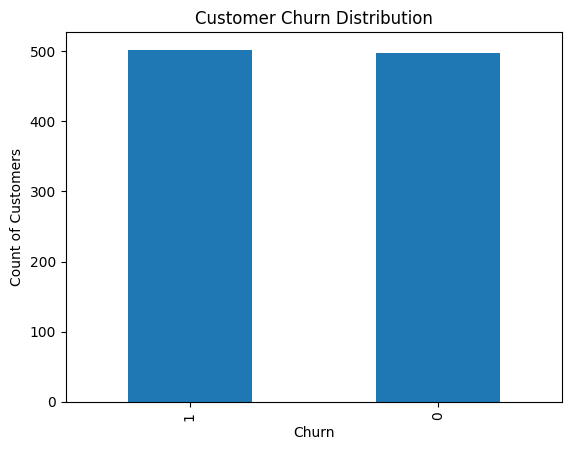

In [0]:
import matplotlib.pyplot as plt



df['Churn'].value_counts().plot(kind='bar')

plt.xlabel('Churn')
plt.ylabel('Count of Customers')
plt.title('Customer Churn Distribution')

plt.show()

In [0]:

df['Churn'].value_counts()


Churn
1    502
0    498
Name: count, dtype: int64

In [0]:
for i, predictor in enumerate(df.drop(columns=['Churn', 'CustomerID','Age','Tenure','TotalCharges', 'MonthlyCharges'])):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='Churn')

---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
File <command-7469211387373707>, line 1
----> 1 for i, predictor in enumerate(df.drop(columns=['Churn', 'CustomerID','Age','Tenure','TotalCharges', 'MonthlyCharges'])):
      2     plt.figure(i)
      3     sns.countplot(data=df, x=predictor, hue='Churn')

File /databricks/python/lib/python3.12/site-packages/pandas/core/frame.py:5581, in DataFrame.drop(self, labels, axis, index, columns, level, inplace, errors)
   5433 def drop(
   5434     self,
   5435     labels: IndexLabel | None = None,
   (...)
   5442     errors: IgnoreRaise = "raise",
   5443 ) -> DataFrame | None:
   5444     """
   5445     Drop specified labels from rows or columns.
   5446 
   (...)
   5579             weight  1.0     0.8
   5580     """
-> 5581     return super().drop(
   5582         labels=labels,
   5583         axis=axis,
   5584         index=index,
  


Numeric correlation matrix:


Age,MonthlyCharges,TotalCharges,IsActiveMember,Churn
1.0,-0.03063788784208083,-0.003163768265707225,0.039812598199358694,-0.014557289707369565
-0.03063788784208083,1.0,-0.01185042861898708,-0.009036887973464868,-0.011805134629759026
-0.003163768265707225,-0.01185042861898708,1.0,0.00997221603605386,0.06006167312331609
0.039812598199358694,-0.009036887973464868,0.00997221603605386,1.0,0.045977195409379654
-0.014557289707369565,-0.011805134629759026,0.06006167312331609,0.045977195409379654,1.0


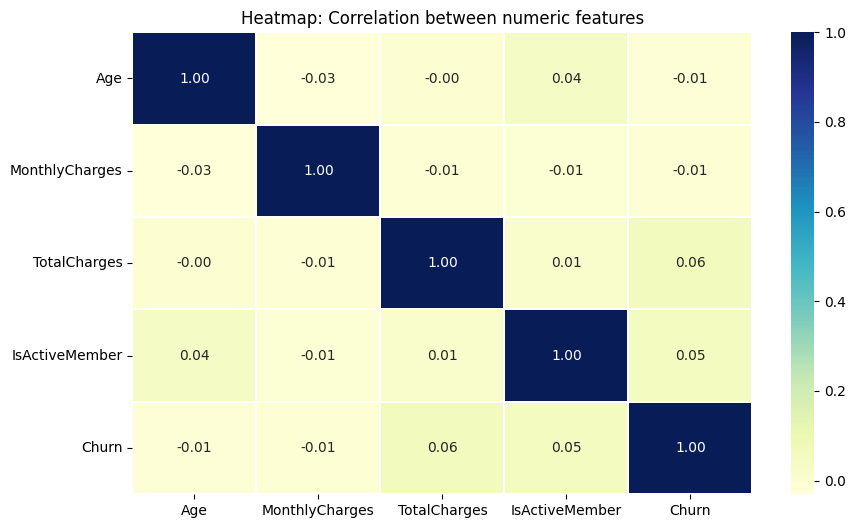

In [0]:
# Heatmap - correlation of numeric features
num_df = df.select_dtypes(include=[np.number])
if num_df.shape[1] >= 2:
    corr = num_df.corr()
    print("\nNumeric correlation matrix:")
    display(corr)
    plt.figure(figsize=(10,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.3)
    plt.title("Heatmap: Correlation between numeric features")
    plt.show()
else:
    print("\nNo numeric columns (or too few) for correlation heatmap.")

In [0]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    'target',
    when(col('y') == 'yes', 1).when(col('y') == 'no', 0)
)


---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
~/.ipykernel/1979/command-4514966954718675-414084593 in ?()
      1 from pyspark.sql.functions import when, col
      2 
----> 3 df = df.withColumn(
      4     'target',
      5     when(col('y') == 'yes', 1).when(col('y') == 'no', 0)
      6 )

/databricks/python/lib/python3.12/site-packages/pandas/core/generic.py in ?(self, name)
   6295             and name not in self._accessors
   6296             and self._info_axis._can_hold_identifiers_and_holds_name(name)
   6297         ):
   6298             return self[name]
-> 6299         return object.__getattribute__(self, name)

AttributeError: 'DataFrame' object has no attribute 'withColumn'

In [0]:
import seaborn as sns 

In [0]:
df_dummies = pd.get_dummies(df)
df_dummies.head()

,Unnamed: 0,Age,MonthlyCharges,TotalCharges,IsActiveMember,Churn,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,Geography_Spain,Geography_UK,Contract_Month-to-month,Contract_One-year,Contract_Two-year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Direct debit,PaymentMethod_Electronic check,tenure_group_1 - 10,tenure_group_11 - 20,tenure_group_21 - 30,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,0,34,21.58,7933.34,1,0,False,True,True,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
1,1,26,27.71,5869.34,0,1,True,False,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
2,2,50,111.12,6321.20,1,0,False,True,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
3,3,37,55.49,7956.44,0,1,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
4,4,30,62.48,4922.75,1,0,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False


/home/spark-de3db90c-0822-4753-86e2-6d/.ipykernel/10755/command-8473728446549374-313319385:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(df_dummies.MonthlyCharges[(df_dummies["Churn"] == 0) ],
/home/spark-de3db90c-0822-4753-86e2-6d/.ipykernel/10755/command-8473728446549374-313319385:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  Mth = sns.kdeplot(df_dummies.MonthlyCharges[(df_dummies["Churn"] == 1) ],


Text(0.5, 1.0, 'Monthly charges by churn')

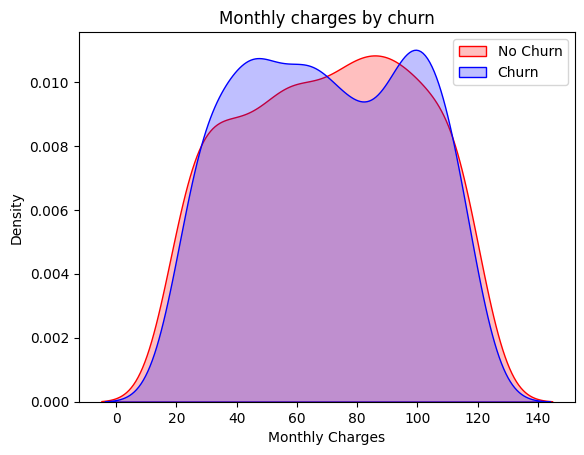

In [0]:
Mth = sns.kdeplot(df_dummies.MonthlyCharges[(df_dummies["Churn"] == 0) ],
                color="Red", shade = True)
Mth = sns.kdeplot(df_dummies.MonthlyCharges[(df_dummies["Churn"] == 1) ],
                ax =Mth, color="Blue", shade= True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly charges by churn')

Text(0.5, 1.0, 'Total charges by churn')

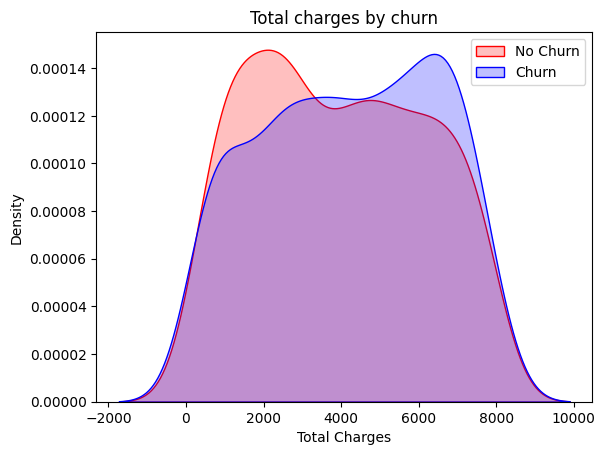

In [0]:
Mth = sns.kdeplot(df_dummies.TotalCharges[(df_dummies["Churn"] == 0) ],
                color="Red", shade = True)
Mth = sns.kdeplot(df_dummies.TotalCharges[(df_dummies["Churn"] == 1) ],
                ax =Mth, color="Blue", shade= True)
Mth.legend(["No Churn","Churn"],loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Total Charges')
Mth.set_title('Total charges by churn')

<Axes: >

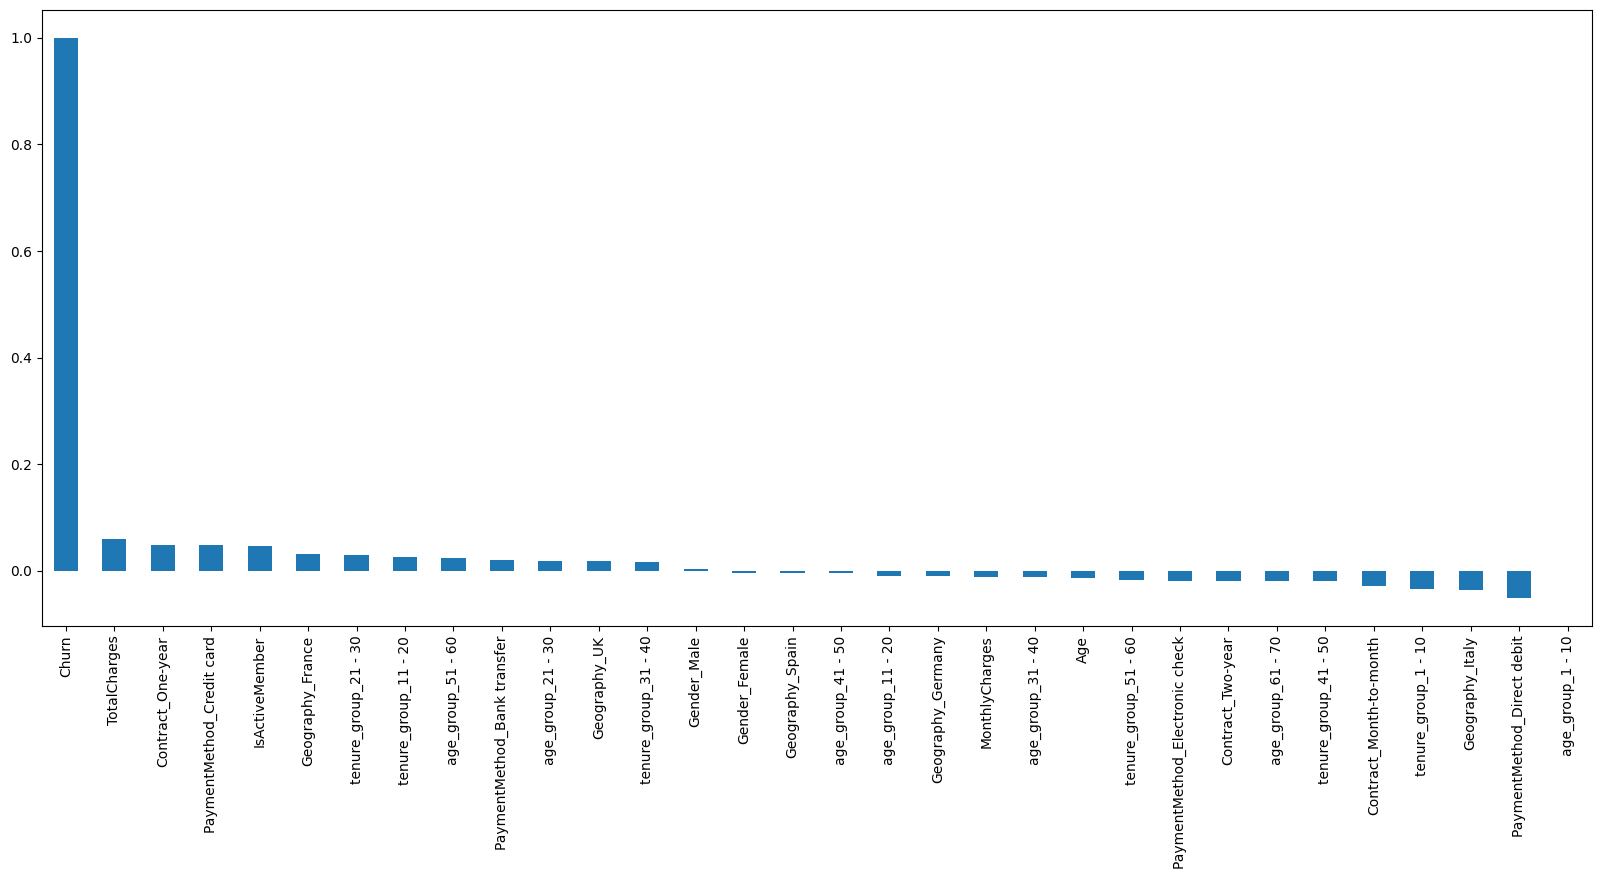

In [0]:
plt.figure(figsize=(20,8))
df_dummies.corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

In [0]:
display(df)

Gender,Age,Geography,Contract,MonthlyCharges,TotalCharges,PaymentMethod,IsActiveMember,Churn,tenure_group,age_group
Male,34,France,Two-year,21.58,7933.34,Bank transfer,1,0,11 - 20,31 - 40
Female,26,Spain,Month-to-month,27.71,5869.34,Credit card,0,1,11 - 20,21 - 30
Male,50,Germany,Two-year,111.12,6321.2,Bank transfer,1,0,51 - 60,41 - 50
Male,37,Spain,Month-to-month,55.49,7956.44,Bank transfer,0,1,31 - 40,31 - 40
Male,30,Spain,Two-year,62.48,4922.75,Direct debit,1,0,51 - 60,21 - 30
Female,45,Italy,Month-to-month,41.53,2601.51,Credit card,0,1,51 - 60,41 - 50
Male,65,UK,Two-year,79.71,6732.74,Credit card,0,1,11 - 20,61 - 70
Male,46,Germany,One-year,79.48,4992.99,Bank transfer,1,1,11 - 20,41 - 50
Male,30,Spain,Two-year,57.22,4733.32,Direct debit,1,1,11 - 20,21 - 30
Female,63,Germany,Two-year,53.3,2178.36,Credit card,1,1,51 - 60,61 - 70


In [0]:
df['Churn'] = np.where(df.Churn == 'Yes',1,0)

In [0]:
df.head()

,CustomerID,Gender,Age,Geography,Tenure,Contract,MonthlyCharges,TotalCharges,PaymentMethod,IsActiveMember,Churn,tenure_group,age_group
0,1000001,Male,34,France,14,Two-year,21.58,7933.34,Bank transfer,1,0,11 - 20,31 - 40
1,1000002,Female,26,Spain,14,Month-to-month,27.71,5869.34,Credit card,0,1,11 - 20,21 - 30
2,1000003,Male,50,Germany,57,Two-year,111.12,6321.20,Bank transfer,1,0,51 - 60,41 - 50
3,1000004,Male,37,Spain,34,Month-to-month,55.49,7956.44,Bank transfer,0,1,31 - 40,31 - 40
4,1000005,Male,30,Spain,53,Two-year,62.48,4922.75,Direct debit,1,0,51 - 60,21 - 30


In [0]:
df['Churn'].value_counts()


Churn
1    502
0    498
Name: count, dtype: int64

<Axes: >

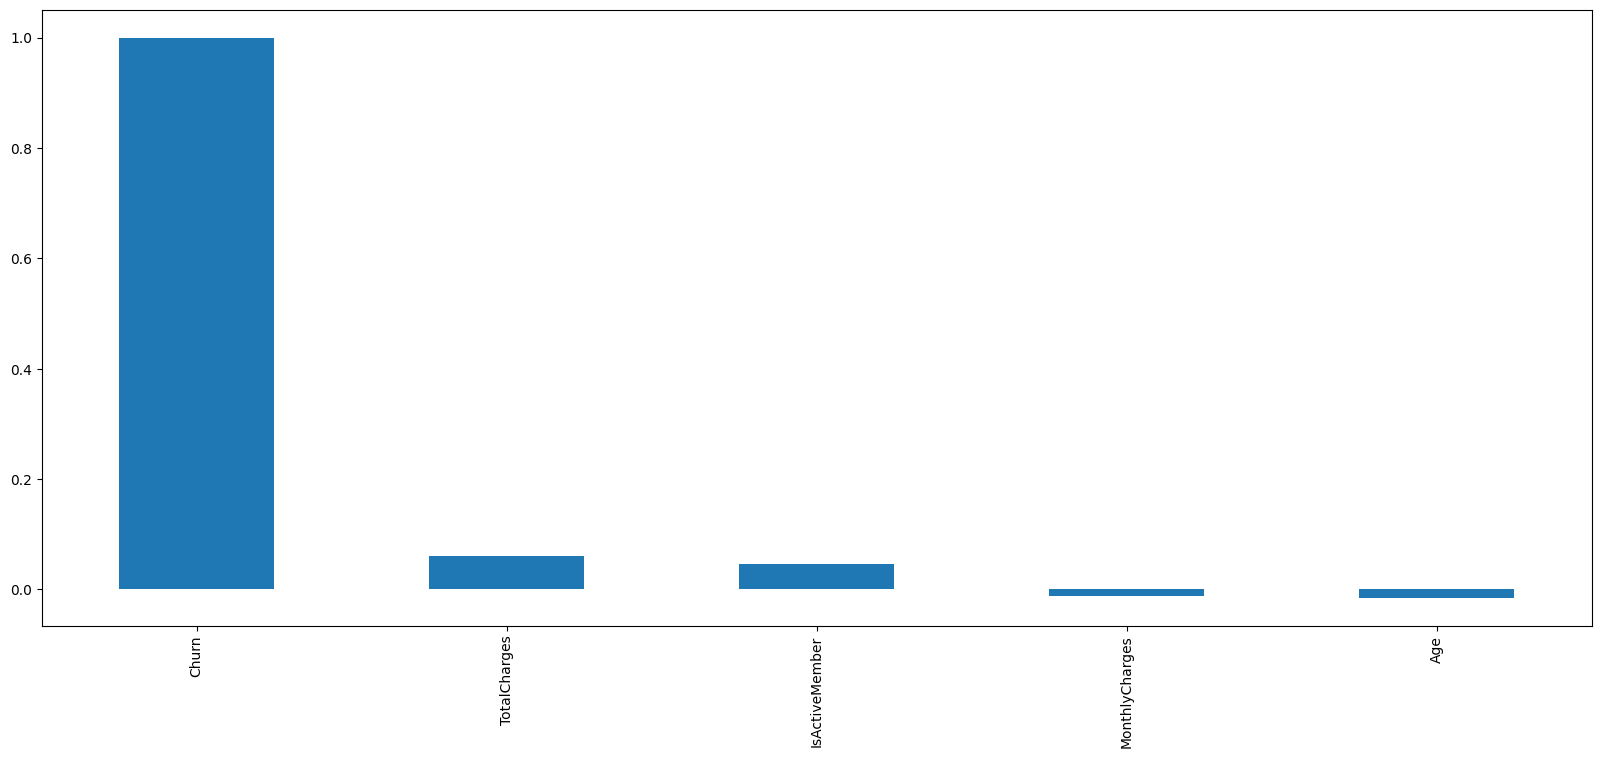

In [0]:
plt.figure(figsize=(20,8))
df.select_dtypes(include=["number"]).corr()['Churn'].sort_values(ascending = False).plot(kind='bar')

<Axes: >

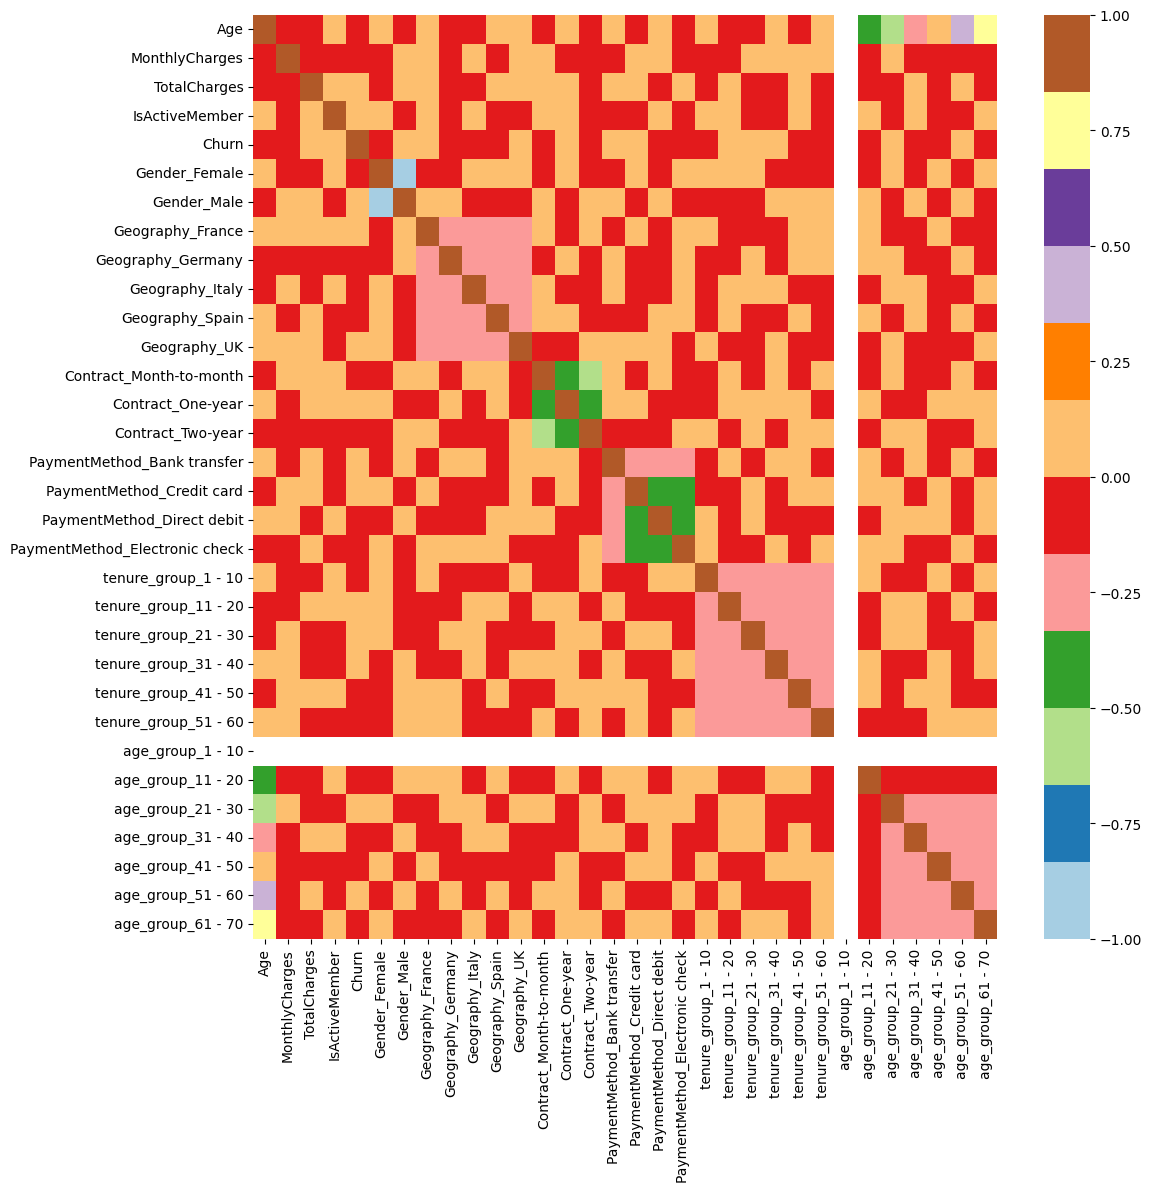

In [0]:
plt.figure(figsize=(12,12))
sns.heatmap(df_dummies.corr(), cmap="Paired")

In [0]:
new_df1=df.loc[df["Churn"]==0]
new_df0=df.loc[df["Churn"]==1]

In [0]:
new_df0=df.loc[df["Churn"]==1]

In [0]:
new_df0.head()

,CustomerID,Gender,Age,Geography,Tenure,Contract,MonthlyCharges,TotalCharges,PaymentMethod,IsActiveMember,Churn,tenure_group,age_group
1,1000002,Female,26,Spain,14,Month-to-month,27.71,5869.34,Credit card,0,1,11 - 20,21 - 30
3,1000004,Male,37,Spain,34,Month-to-month,55.49,7956.44,Bank transfer,0,1,31 - 40,31 - 40
5,1000006,Female,45,Italy,57,Month-to-month,41.53,2601.51,Credit card,0,1,51 - 60,41 - 50
6,1000007,Male,65,UK,20,Two-year,79.71,6732.74,Credit card,0,1,11 - 20,61 - 70
7,1000008,Male,46,Germany,11,One-year,79.48,4992.99,Bank transfer,1,1,11 - 20,41 - 50


In [0]:
result = (
    df[df.Churn == 1]
      .groupby(["tenure_group", "Gender"])
      .agg(distinct_customer_count=("CustomerID", "nunique"))
      .reset_index()
      .sort_values(["tenure_group", "Gender"])
)
display(result)

---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
File <command-7368502247095778>, line 4
      1 result = (
      2     df[df.Churn == 1]
      3       .groupby(["tenure_group", "Gender"])
----> 4       .agg(distinct_customer_count=("CustomerID", "nunique"))
      5       .reset_index()
      6       .sort_values(["tenure_group", "Gender"])
      7 )
      8 display(result)

File /databricks/python/lib/python3.12/site-packages/pandas/core/groupby/generic.py:1432, in DataFrameGroupBy.aggregate(self, func, engine, engine_kwargs, *args, **kwargs)
   1429     kwargs["engine_kwargs"] = engine_kwargs
   1431 op = GroupByApply(self, func, args=args, kwargs=kwargs)
-> 1432 result = op.agg()
   1433 if not is_dict_like(func) and result is not None:
   1434     # GH #52849
   1435     if not self.as_index and is_list_like(func):

File /databricks/python/lib/python3.12/site-packages/pandas/core/

In [0]:
def uniplot(df, col, title, hue=None):
    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams["axes.labelsize"] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30

    n_categories = len(df[col].unique())
    n_hue_groups = len(df[hue].unique()) if hue else 1
    width = n_categories + 7 + 4 * n_hue_groups

    fig, ax = plt.subplots()
    fig.set_size_inches(width, 8)
    plt.xticks(rotation=45)
    plt.yscale('linear')
    plt.title(title)
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, hue=hue, palette='bright')
    plt.tight_layout()
    plt.show()

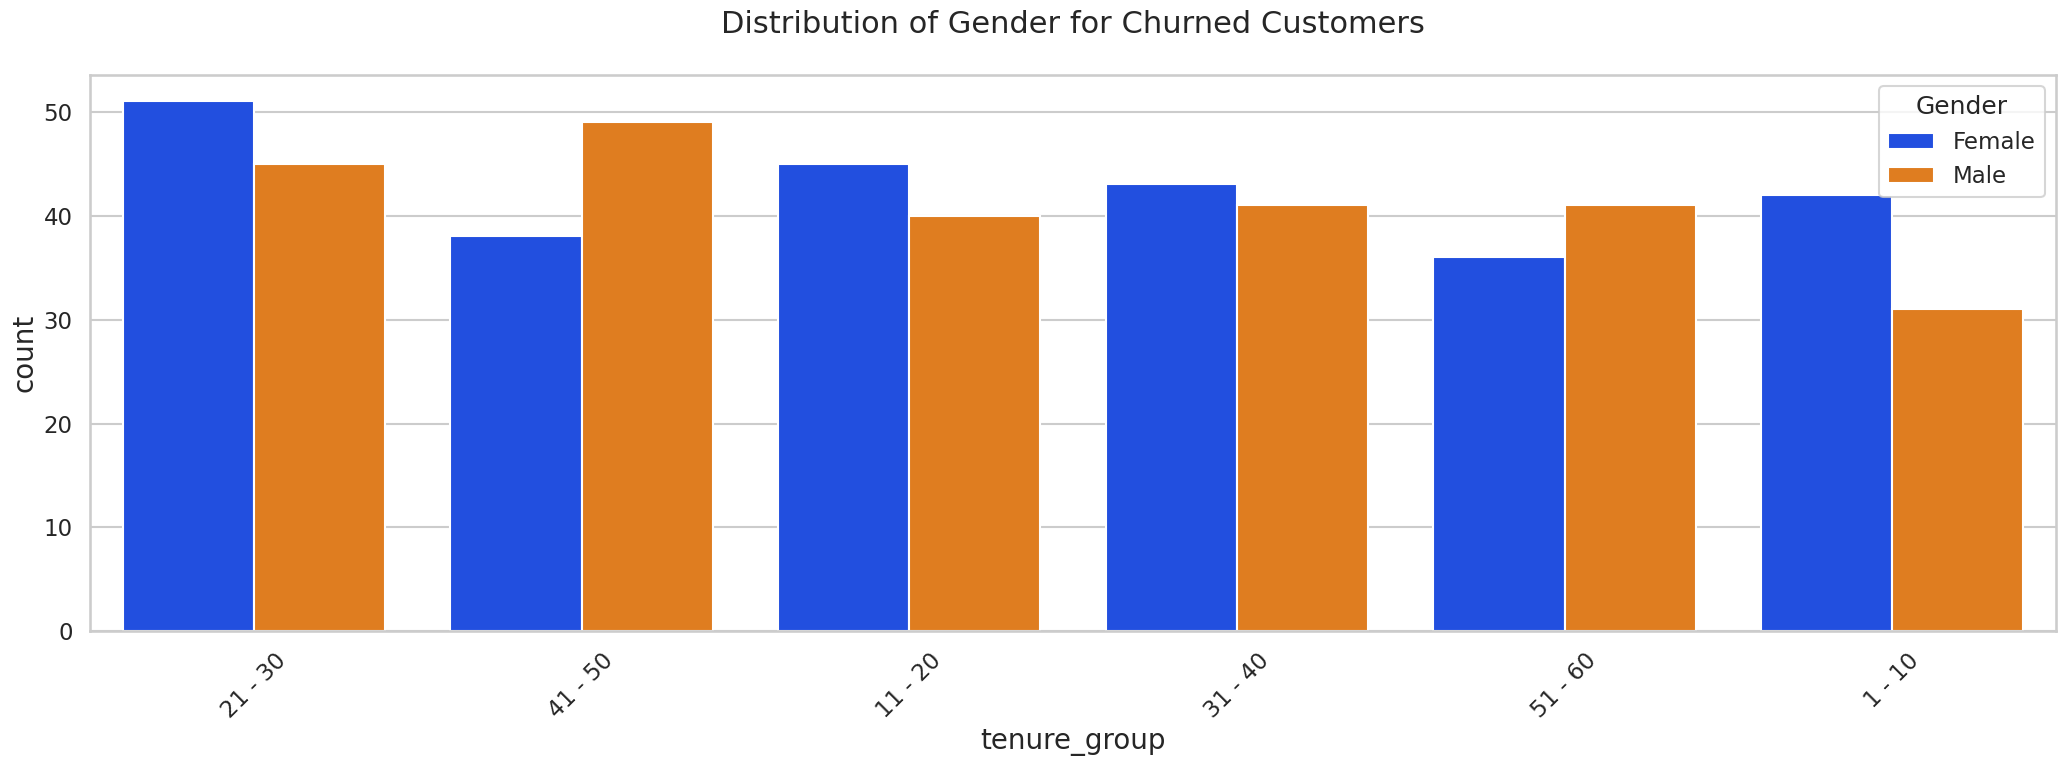

In [0]:
uniplot(new_df0, col='tenure_group', title='Distribution of Gender for Churned Customers', hue='Gender')


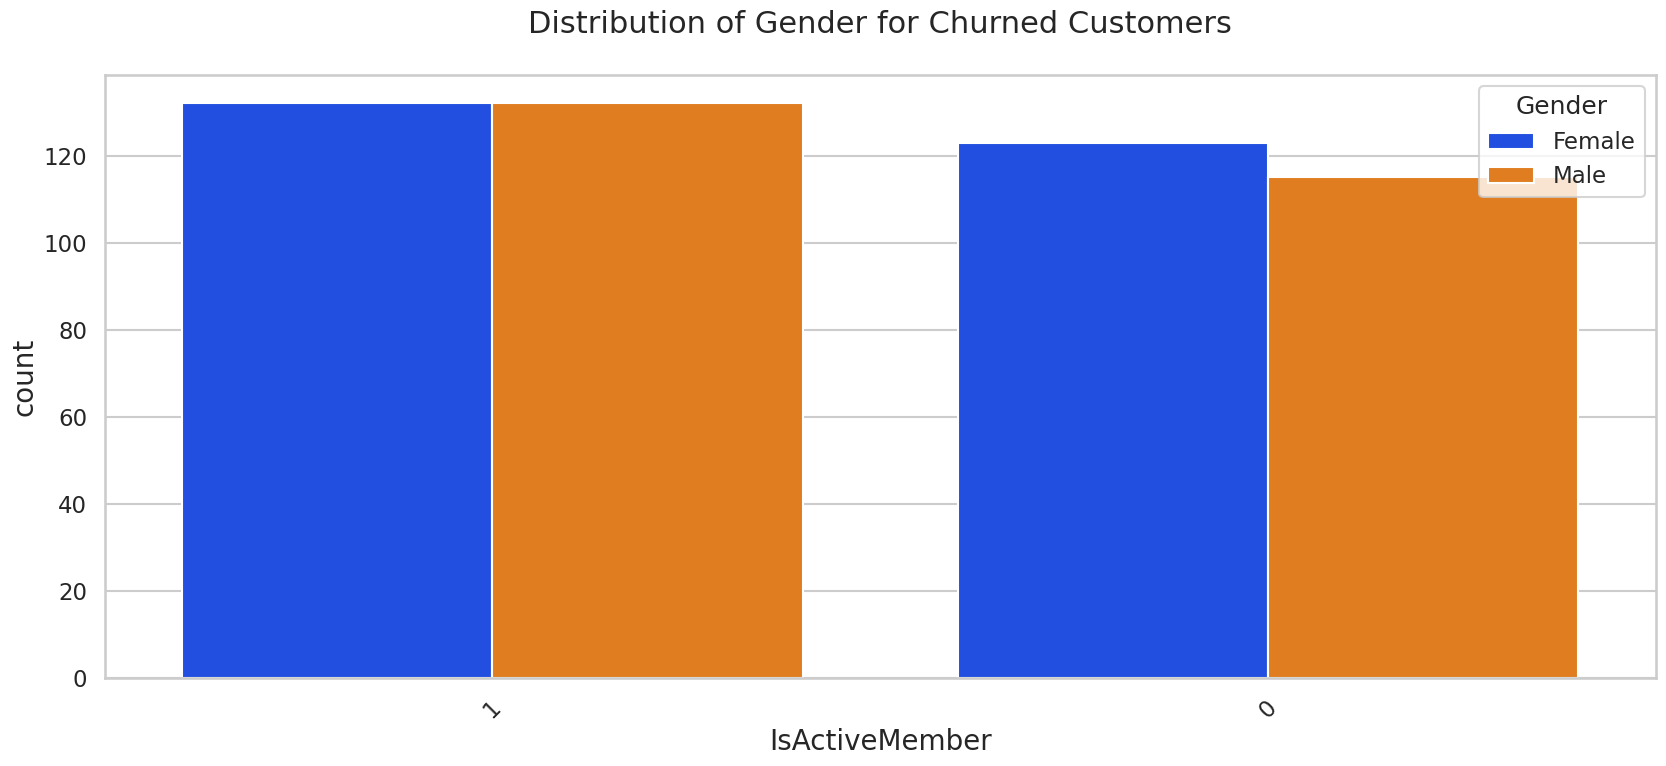

In [0]:
uniplot(new_df0, col='IsActiveMember', title='Distribution of Gender for Churned Customers', hue='Gender')

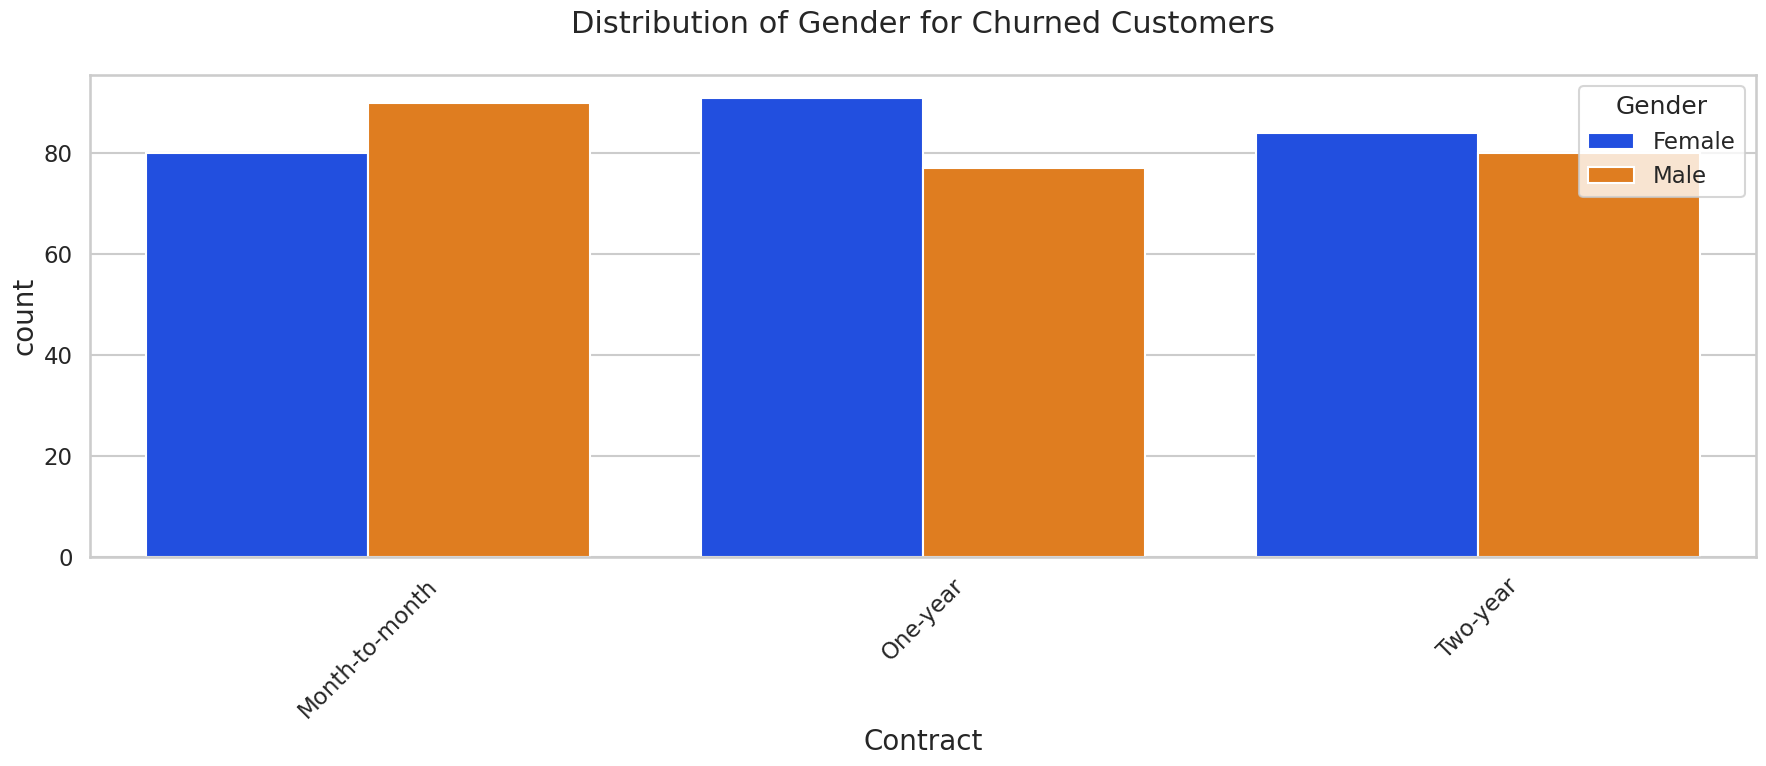

In [0]:
uniplot(new_df0, col='Contract', title='Distribution of Gender for Churned Customers', hue='Gender')

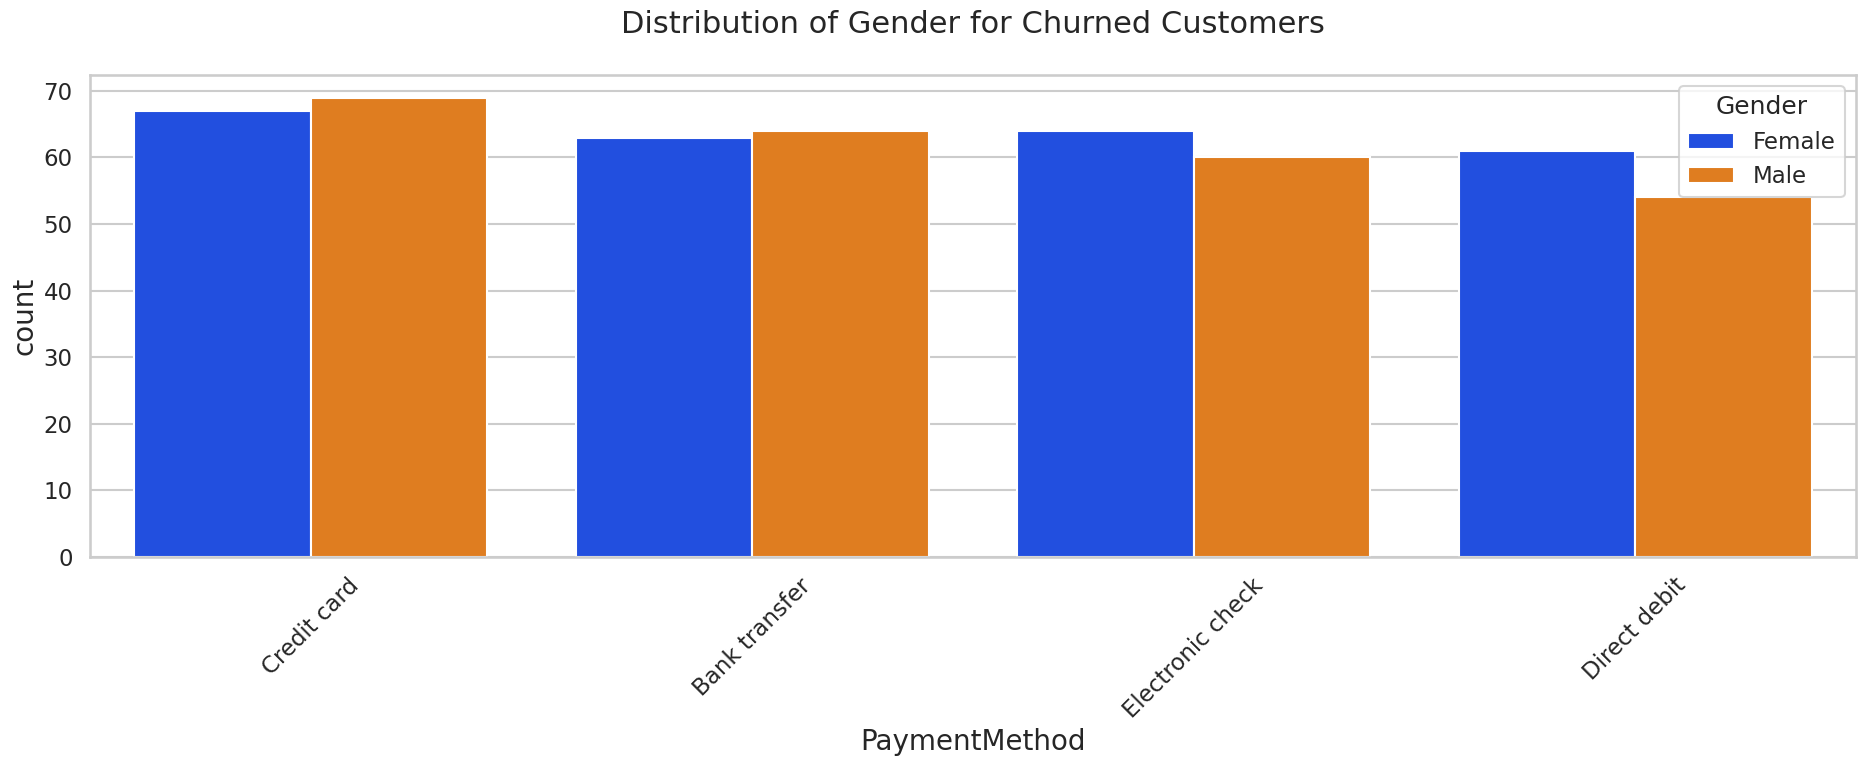

In [0]:
uniplot(new_df0, col='PaymentMethod', title='Distribution of Gender for Churned Customers', hue='Gender')

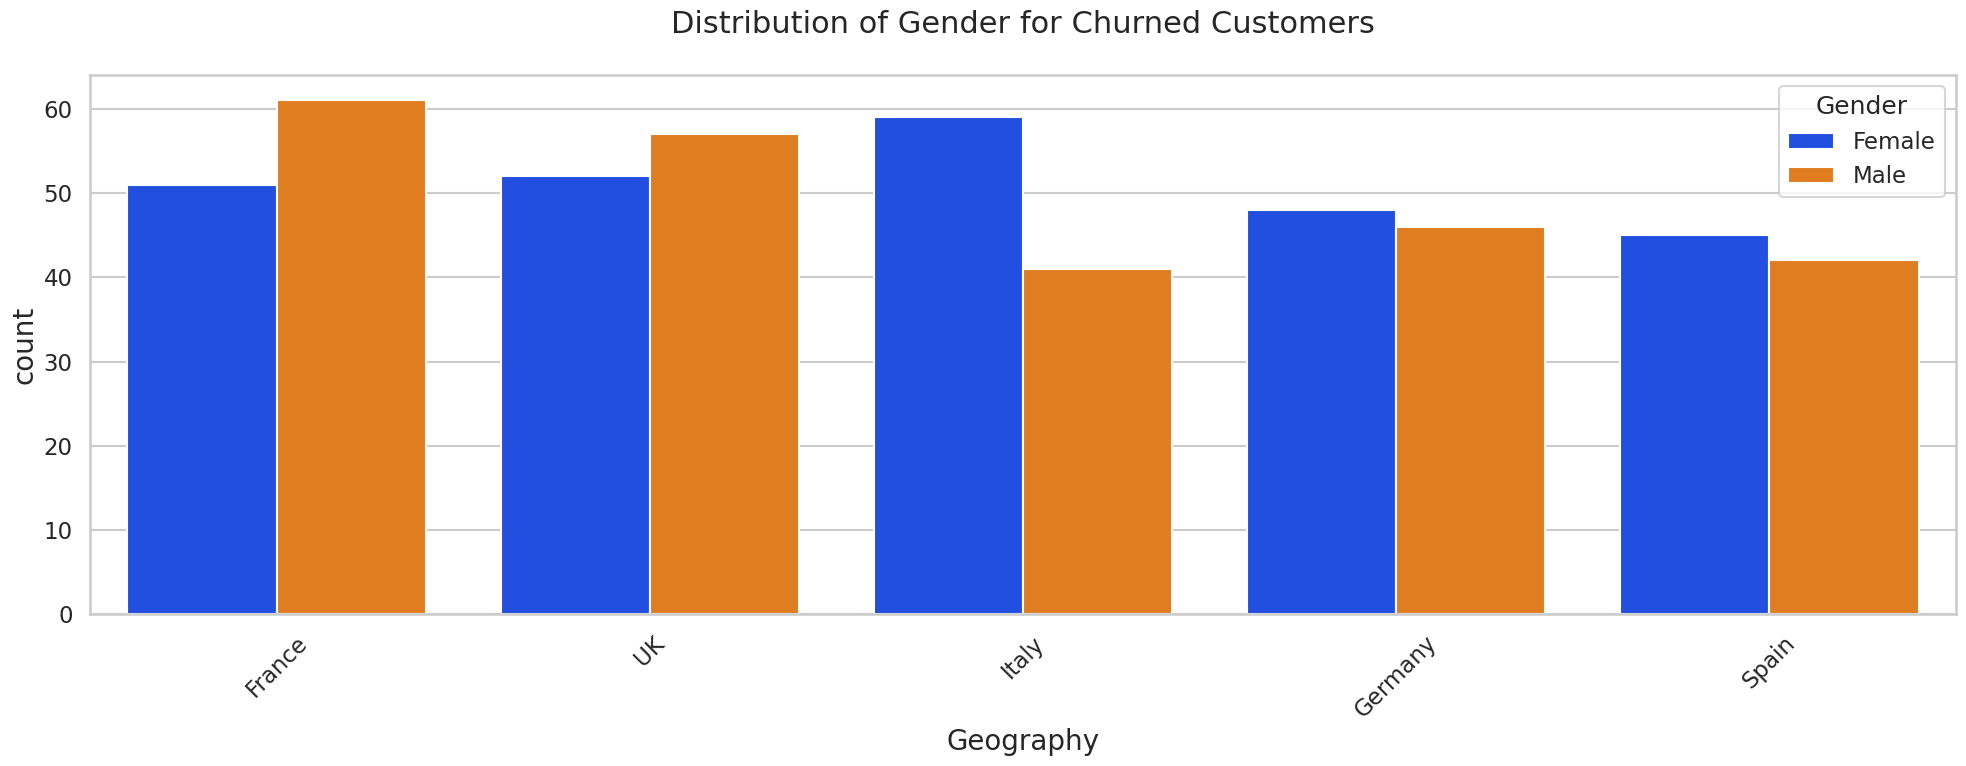

In [0]:
uniplot(new_df0, col='Geography', title='Distribution of Gender for Churned Customers', hue='Gender')

France has more Male churners and Italy,Germany and Spain has more female non-churned customers


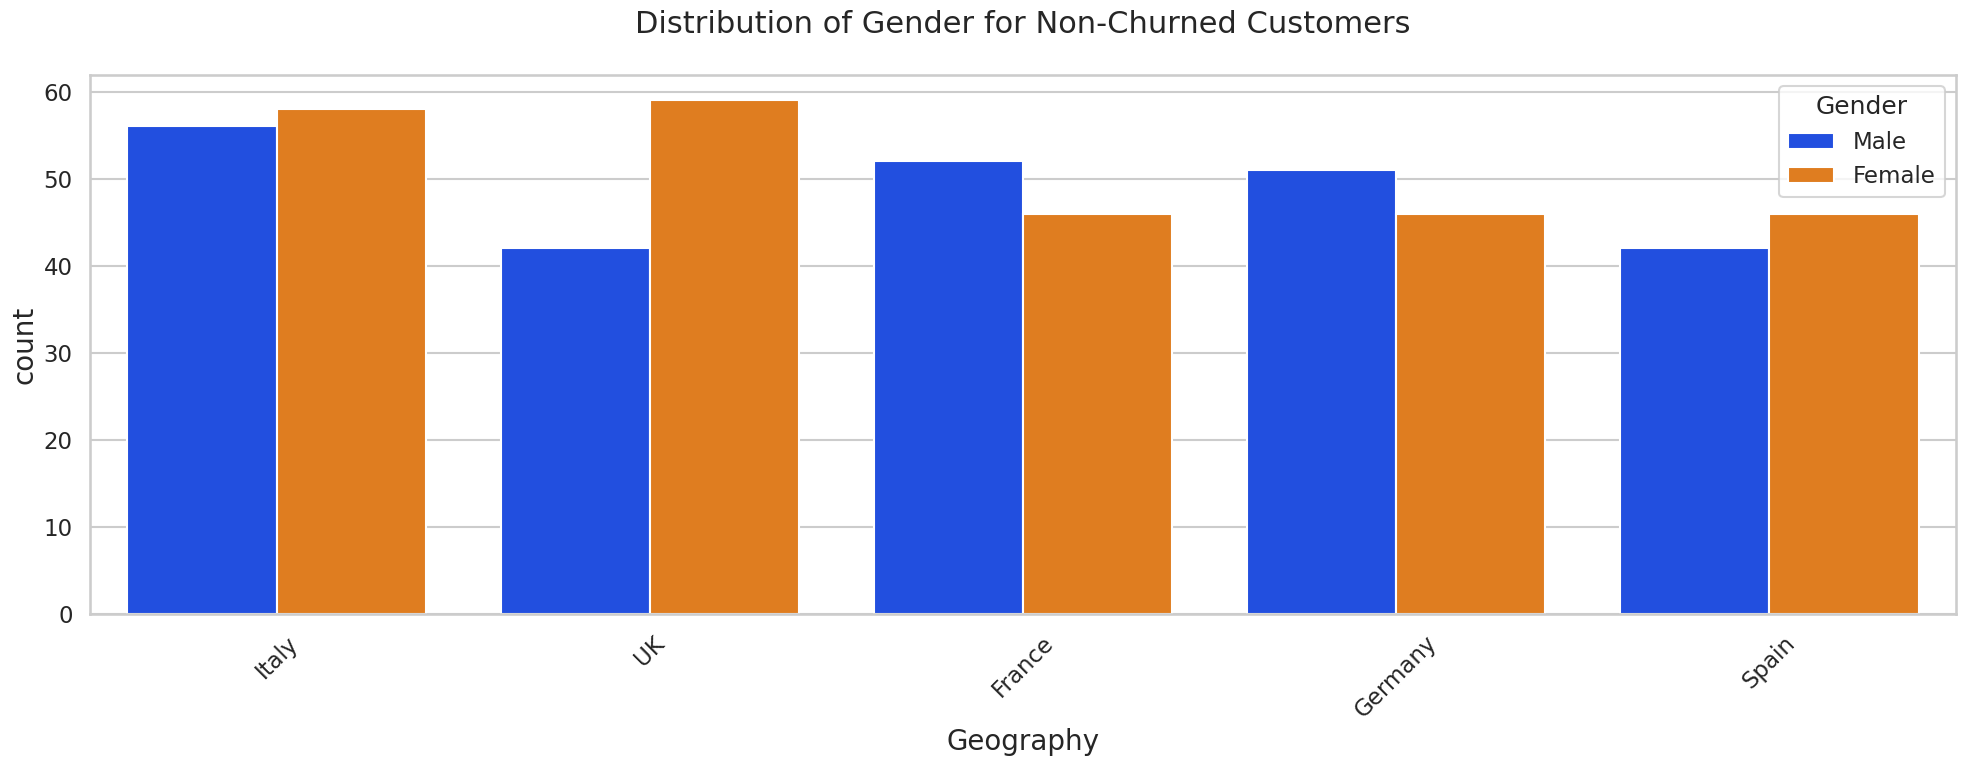

In [0]:
uniplot(new_df1, col='Geography', title='Distribution of Gender for Non-Churned Customers', hue='Gender')

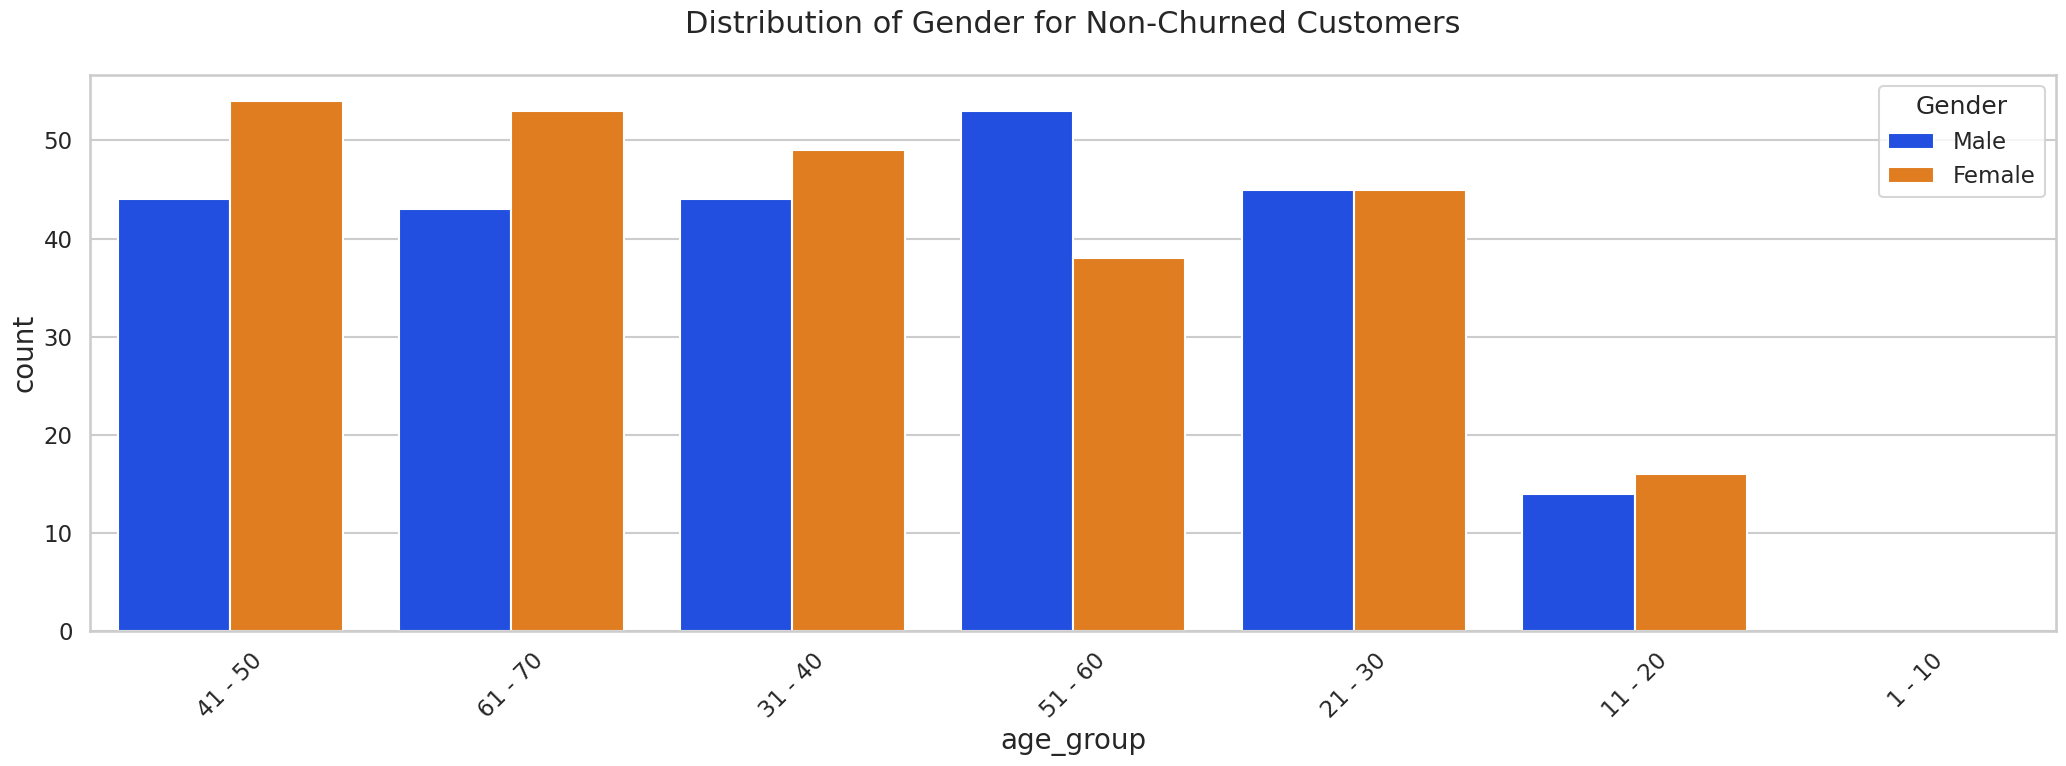

In [0]:
uniplot(new_df1, col='age_group', title='Distribution of Gender for Non-Churned Customers', hue='Gender')

- Non-Churned are Female from 41-50 and 61-70 and Male 51-60
- More Churned customers are Female between 51-60 and 21-30.

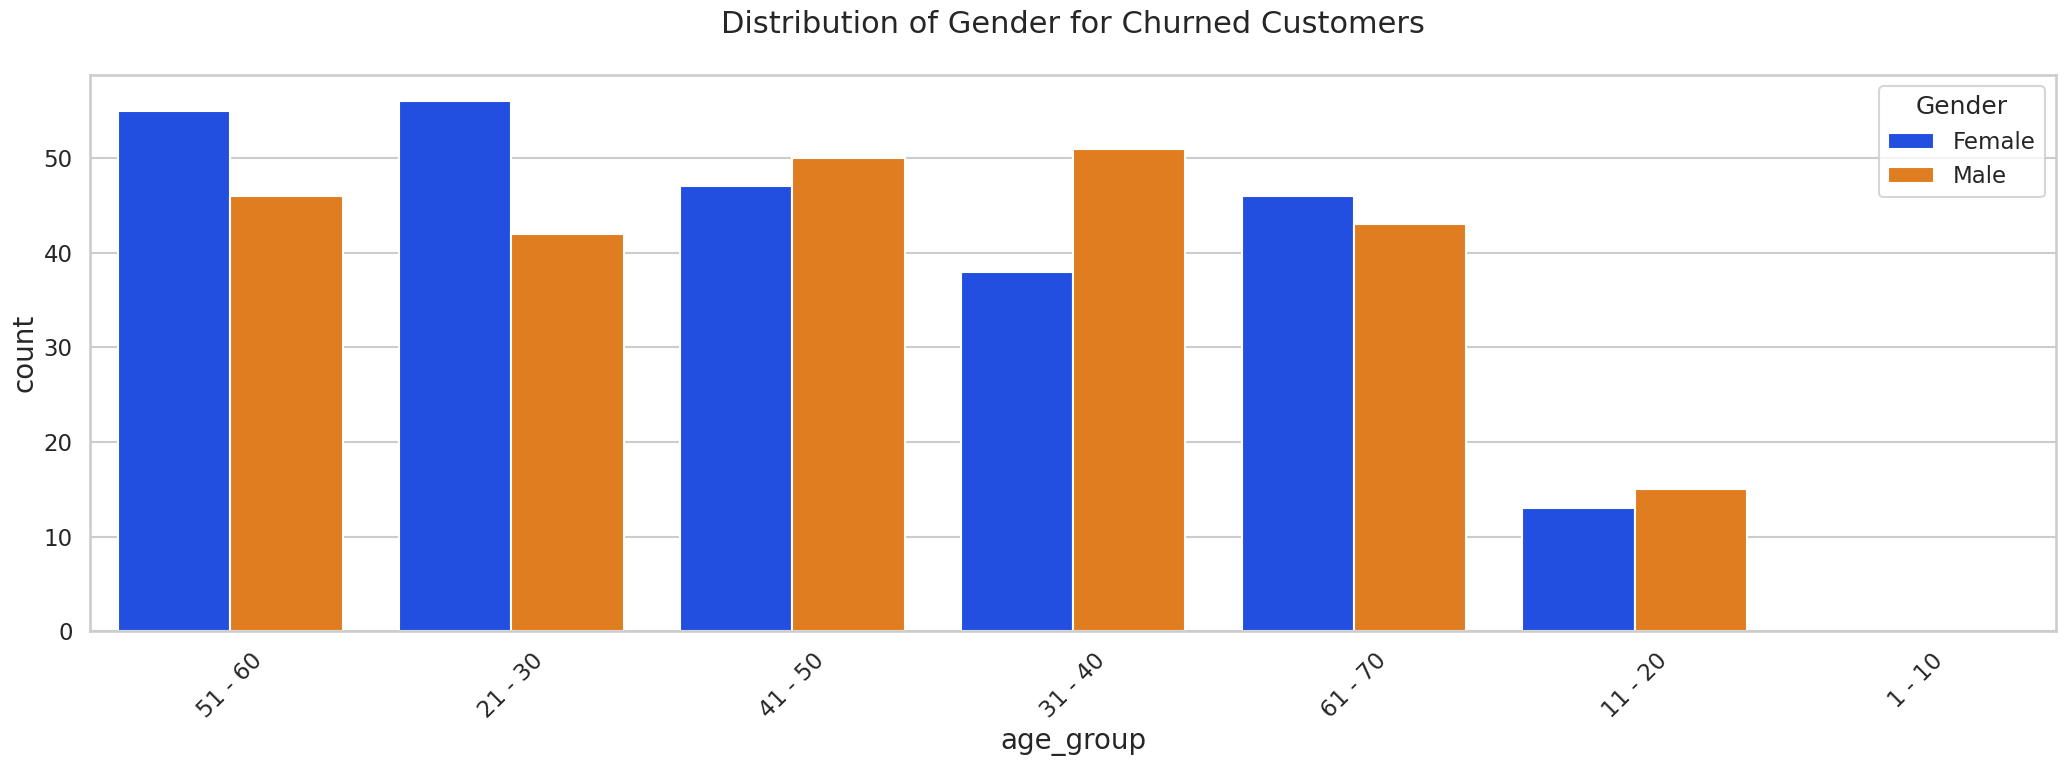

In [0]:
uniplot(new_df0, col='age_group', title='Distribution of Gender for Churned Customers', hue='Gender')

In [0]:
df_dummies.to_csv('df_churn.csv')

In [0]:
%pip install imbalanced-learn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from imblearn.combine import SMOTEENN

In [0]:

df=pd.read_csv("df_churn.csv")
df.head()

,Unnamed: 0,Age,MonthlyCharges,TotalCharges,IsActiveMember,Churn,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,Geography_Spain,Geography_UK,Contract_Month-to-month,Contract_One-year,Contract_Two-year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Direct debit,PaymentMethod_Electronic check,tenure_group_1 - 10,tenure_group_11 - 20,tenure_group_21 - 30,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,0,34,21.58,7933.34,1,0,False,True,True,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
1,1,26,27.71,5869.34,0,1,True,False,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
2,2,50,111.12,6321.20,1,0,False,True,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
3,3,37,55.49,7956.44,0,1,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
4,4,30,62.48,4922.75,1,0,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False


In [0]:
df=df.drop('Unnamed: 0',axis=1)

In [0]:
x = x.replace({False: 0, True: 1})
x

/home/spark-de3db90c-0822-4753-86e2-6d/.ipykernel/10755/command-7002583856823243-1725010273:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x = x.replace({False: 0, True: 1})


,Age,MonthlyCharges,TotalCharges,IsActiveMember,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,Geography_Spain,Geography_UK,Contract_Month-to-month,Contract_One-year,Contract_Two-year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Direct debit,PaymentMethod_Electronic check,tenure_group_1 - 10,tenure_group_11 - 20,tenure_group_21 - 30,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,34,21.58,7933.34,1,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
1,26,27.71,5869.34,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
2,50,111.12,6321.20,1,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
3,37,55.49,7956.44,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
4,30,62.48,4922.75,1,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,42,32.75,6815.82,1,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
996,26,100.02,5544.36,1,0,1,1,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
997,21,106.30,2462.34,1,1,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
998,31,35.07,1771.42,1,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0


In [0]:
x.head()

,Age,MonthlyCharges,TotalCharges,IsActiveMember,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,Geography_Spain,Geography_UK,Contract_Month-to-month,Contract_One-year,Contract_Two-year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Direct debit,PaymentMethod_Electronic check,tenure_group_1 - 10,tenure_group_11 - 20,tenure_group_21 - 30,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,34,21.58,7933.34,1,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
1,26,27.71,5869.34,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
2,50,111.12,6321.20,1,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0
3,37,55.49,7956.44,0,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
4,30,62.48,4922.75,1,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0


In [0]:
x=df.drop('Churn',axis=1)
x

,Age,MonthlyCharges,TotalCharges,IsActiveMember,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Italy,Geography_Spain,Geography_UK,Contract_Month-to-month,Contract_One-year,Contract_Two-year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Direct debit,PaymentMethod_Electronic check,tenure_group_1 - 10,tenure_group_11 - 20,tenure_group_21 - 30,tenure_group_31 - 40,tenure_group_41 - 50,tenure_group_51 - 60,age_group_1 - 10,age_group_11 - 20,age_group_21 - 30,age_group_31 - 40,age_group_41 - 50,age_group_51 - 60,age_group_61 - 70
0,34,21.58,7933.34,1,False,True,True,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
1,26,27.71,5869.34,0,True,False,False,False,False,True,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False
2,50,111.12,6321.20,1,False,True,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
3,37,55.49,7956.44,0,False,True,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
4,30,62.48,4922.75,1,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,42,32.75,6815.82,1,False,True,True,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False
996,26,100.02,5544.36,1,False,True,True,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False
997,21,106.30,2462.34,1,True,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False
998,31,35.07,1771.42,1,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False


In [0]:
y=df['Churn']
y

0      0
1      1
2      0
3      1
4      0
      ..
995    1
996    1
997    0
998    0
999    1
Name: Churn, Length: 1000, dtype: int64

In [0]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

scaler.fit(x_train)

X_train_scaled = scaler.transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [0]:
pd.merge(pd.DataFrame(X_train_scaled), pd.DataFrame(X_test_scaled), how='inner')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30


In [0]:
from sklearn.ensemble import RandomForestClassifier

In [0]:
RandomForestClassifier(class_weight='balanced')

RandomForestClassifier(class_weight='balanced')

In [0]:
model_rf=RandomForestClassifier(n_estimators=100, criterion='gini', random_state = 100,max_depth=6, min_samples_leaf=8)

In [0]:
model_rf.fit(X_train_scaled,y_train)

RandomForestClassifier(max_depth=6, min_samples_leaf=8, random_state=100)

In [0]:
model_rf.feature_importances_

array([0.14529945, 0.17875995, 0.17787173, 0.03424783, 0.02300271,
       0.02115067, 0.01422537, 0.016475  , 0.02155736, 0.01541987,
       0.01727148, 0.02092205, 0.033364  , 0.02237581, 0.02421426,
       0.02251037, 0.01958371, 0.02286153, 0.01690361, 0.01390998,
       0.01312374, 0.01853773, 0.01542829, 0.01173295, 0.        ,
       0.00470499, 0.01644372, 0.01295608, 0.0158912 , 0.01469794,
       0.01455658])

In [0]:
confusion_matrix(y_test, y_pred)

array([[42, 64],
       [33, 61]])

In [0]:
y_pred=model_rf.predict(X_test_scaled)

In [0]:
model_rf.score(X_test_scaled,y_test)

0.485

In [0]:
print(classification_report(y_test, y_pred, labels=[0,1]))

              precision    recall  f1-score   support

           0       0.52      0.42      0.46       106
           1       0.46      0.56      0.51        94

    accuracy                           0.48       200
   macro avg       0.49      0.49      0.48       200
weighted avg       0.49      0.48      0.48       200



In [0]:
sm = SMOTEENN()
X_resampled1, y_resampled1 = sm.fit_sample(x,y)

---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
File <command-7002583856823239>, line 2
      1 sm = SMOTEENN()
----> 2 X_resampled1, y_resampled1 = sm.fit_sample(x,y)

AttributeError: 'SMOTEENN' object has no attribute 'fit_sample'